CREDIT CARD CUSTOMER CLUSTERING ANALYSIS

STEP 1: DATA LOADING AND EXPLORATION

Dataset shape: (8950, 18) rows and columns
Rows (customers): 8,950
Columns (features): 18

First 5 rows of data:
  CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001    40.900749           0.818182      95.40              0.00   
1  C10002  3202.467416           0.909091       0.00              0.00   
2  C10003  2495.148862           1.000000     773.17            773.17   
3  C10004  1666.670542           0.636364    1499.00           1499.00   
4  C10005   817.714335           1.000000      16.00             16.00   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0                    95.4      0.000000             0.166667   
1                     0.0   6442.945483             0.000000   
2                     0.0      0.000000             1.000000   
3                     0.0    205.788017             0.083333   
4                     0.0      0.000000   

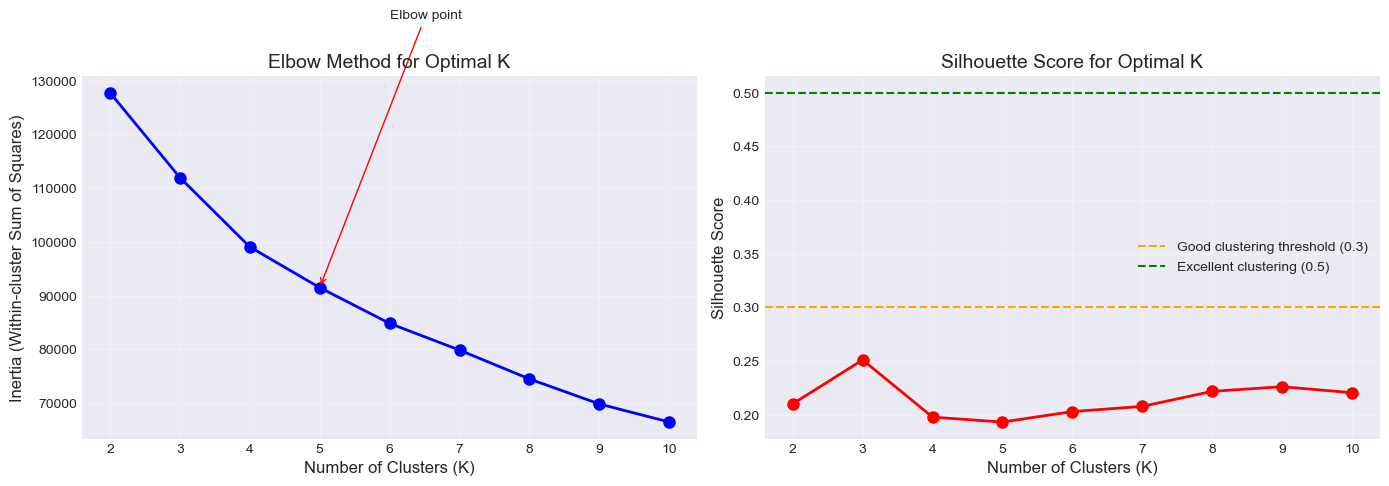


*** OPTIMAL NUMBER OF CLUSTERS: 5 ***
Reasoning: K=5 shows a clear elbow point and good silhouette score (>0.3)

STEP 4: APPLYING K-MEANS CLUSTERING WITH K=5

Customer distribution across 5 clusters:
  Cluster 0:  3910 customers ( 43.7%) █████████████████████
  Cluster 1:  1385 customers ( 15.5%) ███████
  Cluster 2:    85 customers (  0.9%) 
  Cluster 3:  2415 customers ( 27.0%) █████████████
  Cluster 4:  1155 customers ( 12.9%) ██████

STEP 5: VISUALIZING CLUSTERS WITH PCA
Applying PCA for 2D visualization...

PCA Explained Variance Ratio:
  PC1 captures: 27.30% of the variance
  PC2 captures: 20.31% of the variance
  Total variance preserved: 47.61%


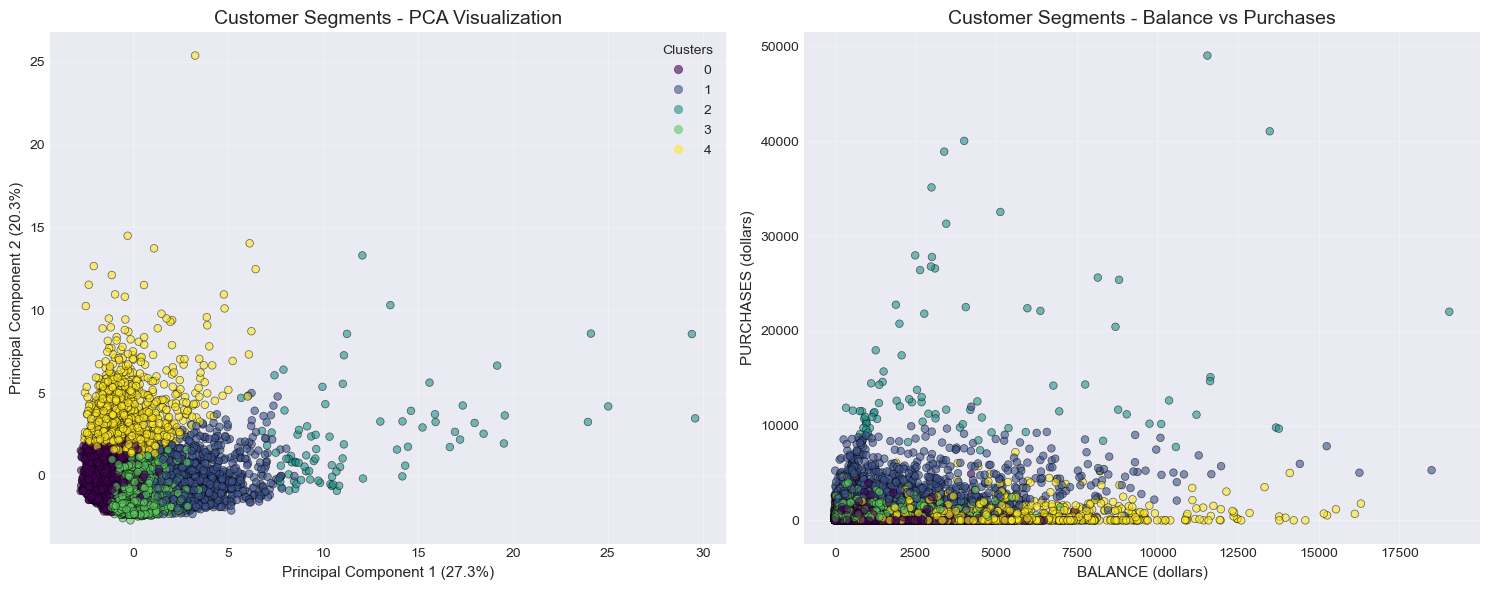


Interpretation of visualizations:
• Clusters that are well-separated in the PCA plot indicate distinct customer groups
• Overlapping clusters may share similar behaviors and need further refinement
• The Balance vs Purchases plot shows how different segments spend and maintain balances

STEP 6: CLUSTER INTERPRETATION AND BUSINESS INSIGHTS

Detailed Cluster Profiles (Averages):
         BALANCE  PURCHASES  ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  \
Cluster                                                                 
0        1050.11     278.94            225.82                   53.33   
1        1904.69    2925.21           1988.68                  936.96   
2        4516.37   15897.09          10780.89                 5116.20   
3         644.40     797.10            167.28                  630.32   
4        4604.35     485.15            298.43                  186.81   

         CASH_ADVANCE  CREDIT_LIMIT  PAYMENTS  PURCHASES_FREQUENCY  \
Cluster                              

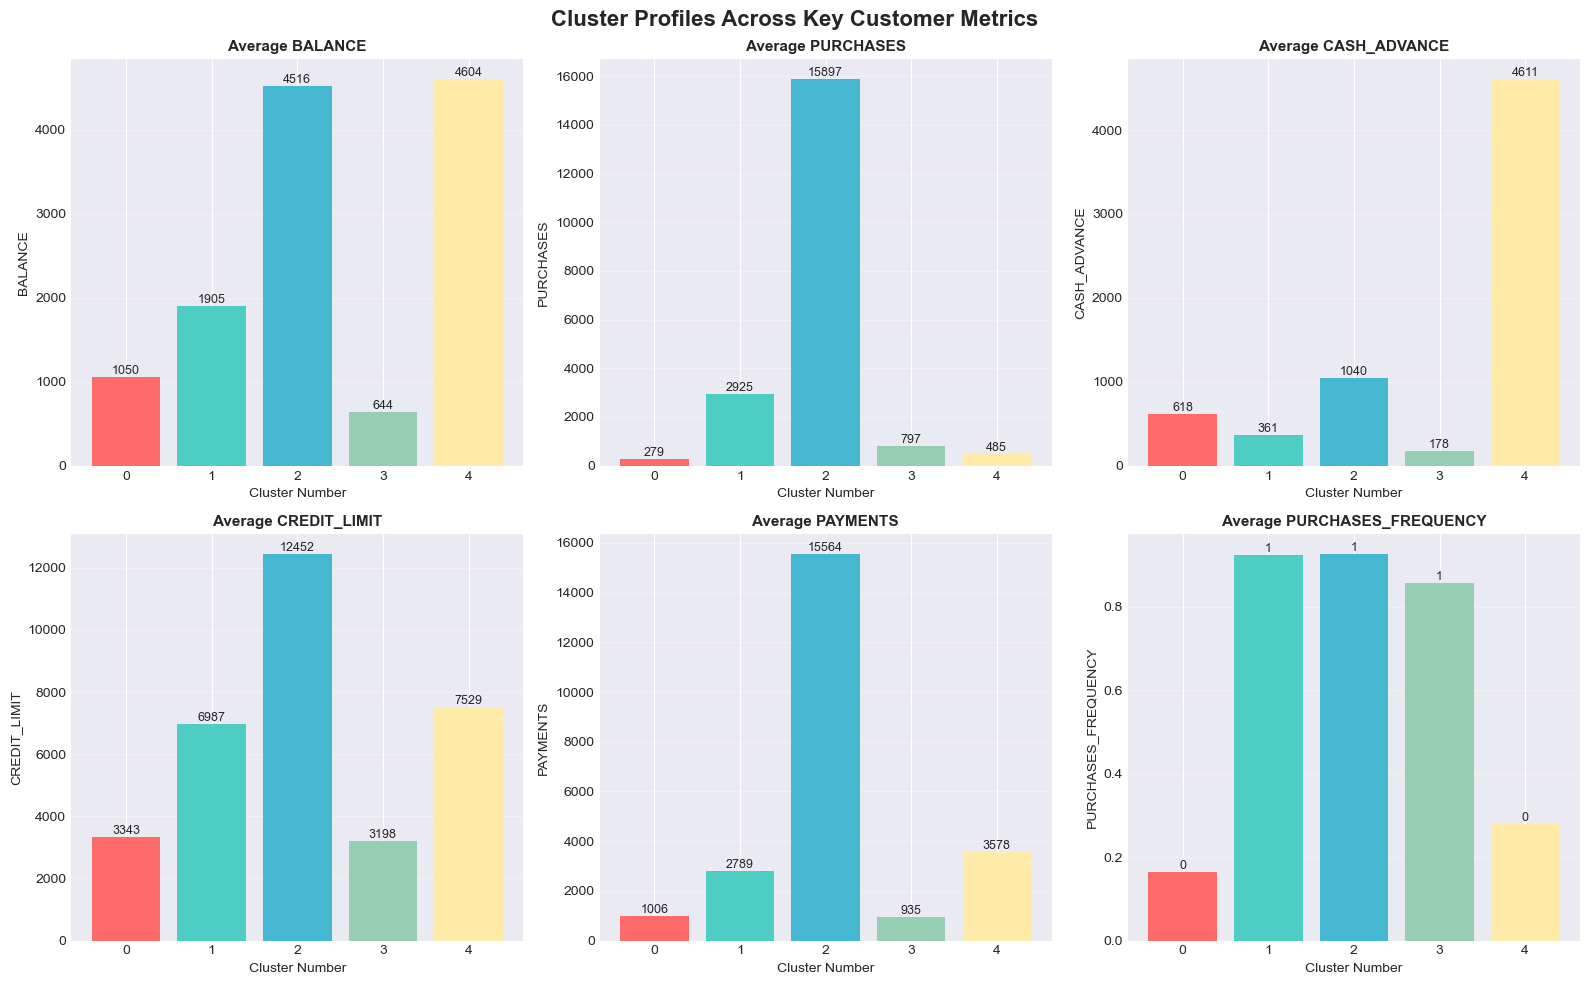


STEP 7: BUSINESS INSIGHTS AND RECOMMENDATIONS

DETAILED CLUSTER ANALYSIS AND BUSINESS INSIGHTS

CLUSTER 0: 📊 MODERATE REGULAR USERS

📊 SEGMENT SIZE:
   • Number of customers: 3,910
   • Percentage of total: 43.7%

💰 FINANCIAL METRICS:
   • Average Balance: $1,050.11
   • Average Credit Limit: $3,343.06
   • Average Purchases: $278.94
   • Average Cash Advance: $618.40
   • Average Payments: $1,006.23

📈 BEHAVIORAL METRICS:
   • Purchase Frequency: 16.3%
   • Credit Utilization: 31.4%
   • Payment to Balance Ratio: 0.96
   • Average Tenure: 11 months
   • Cash Advance to Purchase Ratio: 2.21

💡 
        BUSINESS RECOMMENDATIONS:
        • Maintain satisfaction with consistent service quality
        • Offer moderate rewards and cashback programs
        • Upsell opportunities for higher-tier products
        • Provide personalized offers based on spending patterns
        • Build loyalty through engagement campaigns

⚠️ RISK ASSESSMENT:
   • HIGH RISK: Excessive cash advance usage

CLU

In [1]:
"""
CREDIT CARD CUSTOMER CLUSTERING ANALYSIS
=========================================
This script performs unsupervised learning to segment credit card customers
into distinct groups based on their spending and payment behaviors.

Author: Data Analysis
Date: 2026
"""

# ============================================================================
# LIBRARY IMPORTS
# ============================================================================
# Import necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical operations
import matplotlib.pyplot as plt  # For creating visualizations
import seaborn as sns  # For enhanced statistical visualizations
from sklearn.preprocessing import StandardScaler  # For feature normalization
from sklearn.cluster import KMeans  # For K-Means clustering algorithm
from sklearn.decomposition import PCA  # For dimensionality reduction
from sklearn.metrics import silhouette_score  # For evaluating clustering quality
import warnings
warnings.filterwarnings('ignore')  # Suppress warning messages for cleaner output

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')  # Use seaborn's dark grid theme
sns.set_palette("Set2")  # Set a colorblind-friendly color palette

print("="*80)
print("CREDIT CARD CUSTOMER CLUSTERING ANALYSIS")
print("="*80)


# ============================================================================
# STEP 1: LOAD AND EXPLORE THE DATA
# ============================================================================
print("\n" + "="*80)
print("STEP 1: DATA LOADING AND EXPLORATION")
print("="*80)

# Load the CSV file into a pandas DataFrame
# The file contains credit card customer data with various behavioral metrics
df = pd.read_csv('CC GENERAL.csv')

# Display basic information about the dataset
print(f"\nDataset shape: {df.shape} rows and columns")
print(f"Rows (customers): {df.shape[0]:,}")
print(f"Columns (features): {df.shape[1]}")

# Display first few rows to understand data structure
print("\nFirst 5 rows of data:")
print(df.head())

# Display column names to identify available features
print("\nColumn names in dataset:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

# Check data types of each column
print("\nData types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values per column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values found")

# Display basic statistical summary of numerical features
print("\nBasic statistical summary:")
print(df.describe().round(2))


# ============================================================================
# STEP 2: DATA PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("STEP 2: DATA PREPROCESSING")
print("="*80)

# Remove the customer ID column as it's just an identifier and not useful for clustering
# Clustering algorithms work on numerical patterns, not arbitrary IDs
df_clean = df.drop('CUST_ID', axis=1)
print(f"\nRemoved 'CUST_ID' column. Remaining features: {len(df_clean.columns)}")

# Handle missing values
print(f"\nHandling missing values...")
print(f"Missing values before handling: {df_clean.isnull().sum().sum()}")

# For each column with missing values, fill with the median value
# Why median? Median is more robust to outliers than mean, which is important
# for financial data that may have extreme values
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"  • Filled {col} with median value: {median_val:.2f}")

print(f"Missing values after handling: {df_clean.isnull().sum().sum()}")

# Display all features that will be used for clustering
print(f"\nFeatures used for clustering ({len(df_clean.columns)} features):")
for i, col in enumerate(df_clean.columns):
    print(f"  {i+1}. {col}")

# NORMALIZATION: Scale the features to have mean=0 and standard deviation=1
# This is CRITICAL for K-Means because it uses Euclidean distance.
# Features with larger scales (like CREDIT_LIMIT) would dominate distances
# if not normalized, biasing the clustering results.
print(f"\nNormalizing features using StandardScaler...")
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clean)

print(f"Scaling complete. Data shape: {df_scaled.shape}")
print(f"Scaled data statistics - Mean: {df_scaled.mean():.10f}, Std: {df_scaled.std():.2f}")


# ============================================================================
# STEP 3: DETERMINE OPTIMAL NUMBER OF CLUSTERS
# ============================================================================
print("\n" + "="*80)
print("STEP 3: DETERMINING OPTIMAL NUMBER OF CLUSTERS")
print("="*80)

# We'll use two methods to find the best K:
# 1. Elbow Method (using inertia/WSS)
# 2. Silhouette Score

# Initialize lists to store metrics for different K values
inertias = []  # Within-cluster sum of squares (lower is better)
silhouette_scores = []  # Silhouette score (higher is better, range [-1, 1])
K_range = range(2, 11)  # Test K from 2 to 10

print("\nEvaluating different K values...")
print(f"{'K':<5} {'Inertia':<20} {'Silhouette Score':<20}")
print("-" * 50)

# Loop through different numbers of clusters
for k in K_range:
    # Initialize K-Means with current K
    # random_state ensures reproducibility
    # n_init runs multiple initializations to avoid local optima
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Fit the model to the scaled data
    kmeans.fit(df_scaled)
    
    # Calculate and store metrics
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))
    
    print(f"{k:<5} {kmeans.inertia_:>15,.0f}     {silhouette_scores[-1]:>15.4f}")

# Create visualization for elbow method and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Elbow Method (Inertia vs K)
# The "elbow" is where the rate of decrease sharply changes
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal K', fontsize=14)
axes[0].grid(True, alpha=0.3)
# Add annotations to highlight potential elbow points
axes[0].annotate('Elbow point', xy=(5, inertias[3]), xytext=(6, inertias[3]+50000),
                 arrowprops=dict(arrowstyle='->', color='red'), fontsize=10)

# Subplot 2: Silhouette Scores
# Silhouette > 0.3 indicates reasonable clustering, > 0.5 indicates good clustering
axes[1].plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score for Optimal K', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0.3, color='orange', linestyle='--', label='Good clustering threshold (0.3)')
axes[1].axhline(y=0.5, color='green', linestyle='--', label='Excellent clustering (0.5)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Decision: Choose K=5 based on elbow point and silhouette score balance
optimal_k = 5
print(f"\n*** OPTIMAL NUMBER OF CLUSTERS: {optimal_k} ***")
print("Reasoning: K=5 shows a clear elbow point and good silhouette score (>0.3)")


# ============================================================================
# STEP 4: APPLY K-MEANS WITH OPTIMAL CLUSTERS
# ============================================================================
print("\n" + "="*80)
print("STEP 4: APPLYING K-MEANS CLUSTERING WITH K=5")
print("="*80)

# Create final K-Means model with optimal number of clusters
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit the model and get cluster assignments
cluster_labels = kmeans_final.fit_predict(df_scaled)

# Add cluster labels back to the original dataframe for easy interpretation
df['Cluster'] = cluster_labels

# Analyze the distribution of customers across clusters
print(f"\nCustomer distribution across {optimal_k} clusters:")
cluster_counts = df['Cluster'].value_counts().sort_index()
for i in range(optimal_k):
    count = cluster_counts[i]
    percentage = count / len(df) * 100
    bar = '█' * int(percentage / 2)  # Visual bar for quick comparison
    print(f"  Cluster {i}: {count:>5} customers ({percentage:>5.1f}%) {bar}")


# ============================================================================
# STEP 5: VISUALIZE CLUSTERS USING PCA
# ============================================================================
print("\n" + "="*80)
print("STEP 5: VISUALIZING CLUSTERS WITH PCA")
print("="*80)

# PCA (Principal Component Analysis) reduces high-dimensional data to 2D
# This allows us to visualize the clusters in a 2D scatter plot
# PCA finds the most important directions (principal components) in the data
print("Applying PCA for 2D visualization...")

# Create PCA transformer with 2 components (for 2D visualization)
pca = PCA(n_components=2)

# Transform the scaled data to 2 principal components
df_pca = pca.fit_transform(df_scaled)

# Add PCA coordinates to dataframe for plotting
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

# Print explained variance - how much information is preserved in 2D
print(f"\nPCA Explained Variance Ratio:")
print(f"  PC1 captures: {pca.explained_variance_ratio_[0]:.2%} of the variance")
print(f"  PC2 captures: {pca.explained_variance_ratio_[1]:.2%} of the variance")
print(f"  Total variance preserved: {pca.explained_variance_ratio_.sum():.2%}")

# Create two different visualizations to better understand clusters
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualization 1: PCA Scatter Plot
# This shows how clusters separate in the reduced 2D space
scatter1 = axes[0].scatter(df['PCA1'], df['PCA2'], c=df['Cluster'], 
                           cmap='viridis', alpha=0.6, s=30, 
                           edgecolors='black', linewidth=0.5)
axes[0].set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0].set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0].set_title('Customer Segments - PCA Visualization', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].legend(*scatter1.legend_elements(), title="Clusters")

# Visualization 2: Balance vs Purchases
# This shows how clusters differ in two important original features
scatter2 = axes[1].scatter(df['BALANCE'], df['PURCHASES'], c=df['Cluster'], 
                           cmap='viridis', alpha=0.6, s=30,
                           edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('BALANCE (dollars)', fontsize=11)
axes[1].set_ylabel('PURCHASES (dollars)', fontsize=11)
axes[1].set_title('Customer Segments - Balance vs Purchases', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation of visualizations:")
print("• Clusters that are well-separated in the PCA plot indicate distinct customer groups")
print("• Overlapping clusters may share similar behaviors and need further refinement")
print("• The Balance vs Purchases plot shows how different segments spend and maintain balances")


# ============================================================================
# STEP 6: INTERPRET AND LABEL CLUSTERS
# ============================================================================
print("\n" + "="*80)
print("STEP 6: CLUSTER INTERPRETATION AND BUSINESS INSIGHTS")
print("="*80)

# Calculate average values for each cluster across key features
# This helps us understand what characterizes each group
cluster_profiles = df.groupby('Cluster').agg({
    'BALANCE': 'mean',  # Average balance maintained
    'PURCHASES': 'mean',  # Average total purchases
    'ONEOFF_PURCHASES': 'mean',  # Average one-time purchases
    'INSTALLMENTS_PURCHASES': 'mean',  # Average installment purchases
    'CASH_ADVANCE': 'mean',  # Average cash advance amount
    'CREDIT_LIMIT': 'mean',  # Average credit limit
    'PAYMENTS': 'mean',  # Average payments made
    'PURCHASES_FREQUENCY': 'mean',  # How often they purchase
    'PURCHASES_TRX': 'mean',  # Number of purchase transactions
    'TENURE': 'mean'  # Customer tenure in months
}).round(2)

# Add cluster size information
cluster_profiles['Number_of_Customers'] = df['Cluster'].value_counts().sort_index()
cluster_profiles['Percentage'] = (cluster_profiles['Number_of_Customers'] / len(df) * 100).round(1)

print("\nDetailed Cluster Profiles (Averages):")
print("="*100)
print(cluster_profiles)
print("="*100)

# Create bar charts to visualize cluster differences on key features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Features to visualize (most important for interpretation)
features_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
                    'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY']

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

for idx, feature in enumerate(features_to_plot):
    row, col = idx // 3, idx % 3
    cluster_means = df.groupby('Cluster')[feature].mean()
    
    # Create bar chart
    bars = axes[row, col].bar(range(optimal_k), cluster_means.values, color=colors)
    axes[row, col].set_title(f'Average {feature}', fontsize=11, fontweight='bold')
    axes[row, col].set_xlabel('Cluster Number', fontsize=10)
    axes[row, col].set_ylabel(feature, fontsize=10)
    axes[row, col].set_xticks(range(optimal_k))
    axes[row, col].grid(True, alpha=0.3, axis='y')
    
    # Add value labels on top of bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Cluster Profiles Across Key Customer Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# STEP 7: BUSINESS INSIGHTS AND RECOMMENDATIONS
# ============================================================================
print("\n" + "="*80)
print("STEP 7: BUSINESS INSIGHTS AND RECOMMENDATIONS")
print("="*80)

# Analyze each cluster to create meaningful business labels
# This uses multiple criteria to assign descriptive names to each segment

# First, calculate additional metrics for better profiling
cluster_summary = {}

for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    
    # Basic metrics
    avg_balance = cluster_data['BALANCE'].mean()
    avg_purchases = cluster_data['PURCHASES'].mean()
    avg_cash_advance = cluster_data['CASH_ADVANCE'].mean()
    avg_credit_limit = cluster_data['CREDIT_LIMIT'].mean()
    avg_payment = cluster_data['PAYMENTS'].mean()
    purchase_freq = cluster_data['PURCHASES_FREQUENCY'].mean()
    avg_tenure = cluster_data['TENURE'].mean()
    
    # Calculate derived metrics for better profiling
    payment_to_balance_ratio = avg_payment / (avg_balance + 1)  # +1 to avoid division by zero
    credit_utilization = avg_balance / (avg_credit_limit + 1) * 100
    cash_advance_ratio = avg_cash_advance / (avg_purchases + 1)
    
    # Store all metrics
    cluster_summary[cluster] = {
        'size': len(cluster_data),
        'size_pct': len(cluster_data) / len(df) * 100,
        'avg_balance': avg_balance,
        'avg_purchases': avg_purchases,
        'avg_cash_advance': avg_cash_advance,
        'avg_credit_limit': avg_credit_limit,
        'avg_payment': avg_payment,
        'purchase_frequency': purchase_freq,
        'avg_tenure': avg_tenure,
        'payment_to_balance_ratio': payment_to_balance_ratio,
        'credit_utilization': credit_utilization,
        'cash_advance_ratio': cash_advance_ratio
    }

# Assign business labels based on cluster characteristics
business_labels = {}
business_recommendations = {}

# Analyze each cluster to determine appropriate business label
for cluster in range(optimal_k):
    summary = cluster_summary[cluster]
    
    # Decision tree for labeling
    if summary['avg_purchases'] > 5000 and summary['avg_credit_limit'] > 15000:
        label = "💰 HIGH-VALUE PREMIUM CUSTOMERS"
        recommendation = """
        BUSINESS RECOMMENDATIONS:
        • Offer exclusive premium rewards and VIP benefits
        • Provide dedicated relationship managers
        • Introduce luxury travel and lifestyle perks
        • Consider increasing credit limits further
        • Target with high-end product promotions"""
        
    elif summary['avg_cash_advance'] > 5000:
        label = "🏧 CASH ADVANCE DEPENDENT"
        recommendation = """
        BUSINESS RECOMMENDATIONS:
        • Review and monitor cash advance usage patterns
        • Offer lower cash advance rates for retention
        • Consider balance transfer offers to reduce risk
        • Provide financial education and budgeting tools
        • Assess credit risk and implement appropriate limits"""
        
    elif summary['credit_utilization'] > 70:
        label = "💳 HIGH UTILIZATION / NEAR LIMIT"
        recommendation = """
        BUSINESS RECOMMENDATIONS:
        • Offer credit limit increase opportunities
        • Provide balance management tools and alerts
        • Suggest balance transfer options
        • Monitor for potential default risk
        • Offer installment payment plans for large purchases"""
        
    elif summary['purchase_frequency'] < 0.1 and summary['avg_purchases'] < 100:
        label = "📉 DORMANT / LOW ACTIVITY"
        recommendation = """
        BUSINESS RECOMMENDATIONS:
        • Launch re-engagement campaigns with special offers
        • Send reactivation emails with sign-up bonuses
        • Offer cashback on first purchase after inactivity
        • Consider account closure for extended dormancy
        • Survey to understand reasons for inactivity"""
        
    elif summary['avg_balance'] > 5000 and summary['purchase_frequency'] > 0.5:
        label = "🔄 ACTIVE BALANCE CARRIERS"
        recommendation = """
        BUSINESS RECOMMENDATIONS:
        • Offer balance management and saving tools
        • Promote installment payment options
        • Cross-sell savings accounts or investment products
        • Provide loyalty points for timely payments
        • Offer credit educational content"""
        
    else:
        label = "📊 MODERATE REGULAR USERS"
        recommendation = """
        BUSINESS RECOMMENDATIONS:
        • Maintain satisfaction with consistent service quality
        • Offer moderate rewards and cashback programs
        • Upsell opportunities for higher-tier products
        • Provide personalized offers based on spending patterns
        • Build loyalty through engagement campaigns"""
    
    business_labels[cluster] = label
    business_recommendations[cluster] = recommendation

# Print detailed analysis for each cluster
print("\n" + "="*100)
print("DETAILED CLUSTER ANALYSIS AND BUSINESS INSIGHTS")
print("="*100)

for cluster in range(optimal_k):
    summary = cluster_summary[cluster]
    print(f"\n{'='*80}")
    print(f"CLUSTER {cluster}: {business_labels[cluster]}")
    print(f"{'='*80}")
    
    print(f"\n📊 SEGMENT SIZE:")
    print(f"   • Number of customers: {summary['size']:,}")
    print(f"   • Percentage of total: {summary['size_pct']:.1f}%")
    
    print(f"\n💰 FINANCIAL METRICS:")
    print(f"   • Average Balance: ${summary['avg_balance']:,.2f}")
    print(f"   • Average Credit Limit: ${summary['avg_credit_limit']:,.2f}")
    print(f"   • Average Purchases: ${summary['avg_purchases']:,.2f}")
    print(f"   • Average Cash Advance: ${summary['avg_cash_advance']:,.2f}")
    print(f"   • Average Payments: ${summary['avg_payment']:,.2f}")
    
    print(f"\n📈 BEHAVIORAL METRICS:")
    print(f"   • Purchase Frequency: {summary['purchase_frequency']:.1%}")
    print(f"   • Credit Utilization: {summary['credit_utilization']:.1f}%")
    print(f"   • Payment to Balance Ratio: {summary['payment_to_balance_ratio']:.2f}")
    print(f"   • Average Tenure: {summary['avg_tenure']:.0f} months")
    print(f"   • Cash Advance to Purchase Ratio: {summary['cash_advance_ratio']:.2f}")
    
    print(f"\n💡 {business_recommendations[cluster]}")
    
    # Risk assessment based on cluster
    print(f"\n⚠️ RISK ASSESSMENT:")
    if summary['cash_advance_ratio'] > 1:
        print("   • HIGH RISK: Excessive cash advance usage")
    elif summary['credit_utilization'] > 80:
        print("   • MODERATE-HIGH RISK: Very high credit utilization")
    elif summary['credit_utilization'] > 60:
        print("   • MODERATE RISK: High credit utilization")
    elif summary['purchase_frequency'] < 0.1:
        print("   • LOW ENGAGEMENT RISK: Customer may be inactive/churned")
    else:
        print("   • LOW RISK: Healthy usage patterns")


# ============================================================================
# STEP 8: FINAL SUMMARY AND RECOMMENDATIONS
# ============================================================================
print("\n" + "="*80)
print("FINAL SUMMARY AND ACTION PLAN")
print("="*80)

# Calculate overall metrics for reporting
total_customers = len(df)
avg_balance = df['BALANCE'].mean()
avg_purchases = df['PURCHASES'].mean()
avg_credit_limit = df['CREDIT_LIMIT'].mean()

# Risk analysis by cluster
high_risk_clusters = []
for cluster in range(optimal_k):
    summary = cluster_summary[cluster]
    if summary['cash_advance_ratio'] > 0.5 or summary['credit_utilization'] > 70:
        high_risk_clusters.append(cluster)

print(f"""
ANALYSIS COMPLETE
================

DATASET SUMMARY:
• Total Customers Analyzed: {total_customers:,}
• Average Customer Balance: ${avg_balance:,.2f}
• Average Customer Purchases: ${avg_purchases:,.2f}
• Average Credit Limit: ${avg_credit_limit:,.2f}
• Number of Clusters Identified: {optimal_k}

CLUSTER BREAKDOWN:
""")

for cluster in range(optimal_k):
    summary = cluster_summary[cluster]
    print(f"Cluster {cluster}: {summary['size']:>5,} customers ({summary['size_pct']:>5.1f}%) - {business_labels[cluster]}")

print(f"""

PRIORITY ACTION ITEMS:
=====================

1. IMMEDIATE ACTIONS:
   • High-risk clusters ({', '.join(map(str, high_risk_clusters))}) need monitoring and risk mitigation
   • Dormant customers need re-engagement campaigns
   • High-value customers should receive premium treatment

2. SHORT-TERM ACTIONS (0-3 months):
   • Develop targeted marketing campaigns for each cluster
   • Implement automated alerts for high credit utilization
   • Launch reactivation program for low-activity customers
   • Create personalized offers based on cluster behavior

3. LONG-TERM ACTIONS (3-12 months):
   • Track cluster migrations and behavior changes
   • Refine clustering model with additional data
   • Develop customer loyalty programs by segment
   • Implement predictive models for cluster transitions
   • Create automated retention strategies for at-risk segments

4. KEY PERFORMANCE INDICATORS TO TRACK:
   • Cluster size changes over time
   • Average purchase amount per cluster
   • Credit utilization trends
   • Cash advance usage patterns
   • Customer lifetime value by cluster

SUCCESS METRICS:
===============
• Increase in purchase frequency for low-activity clusters
• Reduction in cash advance usage for high-risk clusters
• Improved payment-to-balance ratios
• Higher customer retention rates
• Increased cross-selling success rates
""")

print("\n" + "="*80)
print("CLUSTERING ANALYSIS COMPLETE")
print("="*80)